In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../dataset/Nassau Candy Distributor.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (10194, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

In [3]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

print("Order Date Range:")
print(df["Order Date"].min(), "to", df["Order Date"].max())

print("\nShip Date Range:")
print(df["Ship Date"].min(), "to", df["Ship Date"].max())

Order Date Range:
2024-01-02 00:00:00 to 2025-12-31 00:00:00

Ship Date Range:
2026-06-30 00:00:00 to 2030-06-28 00:00:00


In [7]:
df["Shipping Lead Time"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

print("Lead Time Summary:")
print(df["Shipping Lead Time"].describe())

print("\nNegative Lead Times:")
print((df["Shipping Lead Time"] < 0).sum())

print("\nZero Lead Times:")
print((df["Shipping Lead Time"] == 0).sum())

print("\nLead Time Range:")
print(
    df["Shipping Lead Time"].min(),
    "to",
    df["Shipping Lead Time"].max(),
    "days"
)

Lead Time Summary:
count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Shipping Lead Time, dtype: float64

Negative Lead Times:
0

Zero Lead Times:
0

Lead Time Range:
904 to 1642 days


In [8]:
print(df[[
    "Order Date",
    "Ship Date",
    "Ship Mode",
    "Region"
]].head(15))

   Order Date  Ship Date       Ship Mode    Region
0  2024-01-03 2026-06-30  Standard Class  Interior
1  2024-01-04 2026-07-01  Standard Class  Interior
2  2024-01-04 2026-07-01  Standard Class  Interior
3  2024-01-04 2026-07-01  Standard Class  Interior
4  2024-01-05 2026-07-05  Standard Class  Atlantic
5  2024-01-06 2026-07-03  Standard Class      Gulf
6  2024-01-06 2026-07-03  Standard Class      Gulf
7  2024-01-06 2026-06-30     First Class      Gulf
8  2024-01-06 2026-07-03  Standard Class      Gulf
9  2024-01-06 2026-07-03  Standard Class      Gulf
10 2024-01-06 2026-07-03  Standard Class      Gulf
11 2024-01-06 2026-07-01    Second Class   Pacific
12 2024-01-06 2026-07-03  Standard Class      Gulf
13 2024-01-06 2026-07-03  Standard Class      Gulf
14 2024-01-07 2026-07-05  Standard Class  Interior


In [9]:
print(
    df.groupby("Ship Mode")["Shipping Lead Time"]
      .agg(["count", "min", "max", "mean", "median"])
      .round(2)
)

                count  min   max     mean  median
Ship Mode                                        
First Class      1548  905  1638  1338.28  1272.0
Same Day          547  904  1636  1333.44  1269.0
Second Class     1979  906  1640  1323.85  1273.0
Standard Class   6120  908  1642  1314.33  1274.0


In [10]:
print(
    df[["Order Date", "Ship Date", "Shipping Lead Time"]]
    .sort_values("Shipping Lead Time")
    .head(10)
)

print("\nLongest:")
print(
    df[["Order Date", "Ship Date", "Shipping Lead Time"]]
    .sort_values("Shipping Lead Time", ascending=False)
    .head(10)
)

     Order Date  Ship Date  Shipping Lead Time
1729 2024-11-26 2027-05-19                 904
1696 2024-11-24 2027-05-17                 904
1732 2024-11-28 2027-05-21                 904
454  2024-05-09 2026-10-30                 904
455  2024-05-09 2026-10-30                 904
456  2024-05-09 2026-10-30                 904
424  2024-05-02 2026-10-23                 904
429  2024-05-04 2026-10-25                 904
538  2024-05-27 2026-11-17                 904
540  2024-05-27 2026-11-17                 904

Longest:
      Order Date  Ship Date  Shipping Lead Time
10183 2025-12-29 2030-06-28                1642
10175 2025-12-29 2030-06-28                1642
7167  2025-03-13 2029-09-10                1642
9540  2025-11-19 2030-05-19                1642
10165 2025-12-28 2030-06-27                1642
10164 2025-12-28 2030-06-27                1642
10160 2025-12-28 2030-06-27                1642
8087  2025-07-08 2030-01-05                1642
10120 2025-12-24 2030-06-23              

In [11]:
df[["Order ID", "Order Date", "Ship Date", "Ship Mode"]].head(20)

,Order ID,Order Date,Ship Date,Ship Mode
0,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class
1,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class
2,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class
3,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class
4,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class
5,US-2021-167199-CHO-SCR-58000,2024-01-06,2026-07-03,Standard Class
6,US-2021-167199-CHO-TRI-54000,2024-01-06,2026-07-03,Standard Class
7,US-2021-106054-CHO-MIL-31000,2024-01-06,2026-06-30,First Class
8,US-2021-167199-CHO-NUT-13000,2024-01-06,2026-07-03,Standard Class
9,US-2021-167199-CHO-MIL-31000,2024-01-06,2026-07-03,Standard Class


In [13]:
import re

df["Order ID Year"] = df["Order ID"].str.extract(r"US-(\d{4})-")[0]

print("Order ID Year counts:")
print(df["Order ID Year"].value_counts(dropna=False).sort_index())

print("\nRows where year could not be extracted:")
print(df[df["Order ID Year"].isna()][["Order ID", "Order Date"]].head(20))

Order ID Year counts:
Order ID Year
2021    1993
2022    2102
2023    2587
2024    3312
NaN      200
Name: count, dtype: int64

Rows where year could not be extracted:
                         Order ID Order Date
61   CA-2021-115238-CHO-FUD-51000 2024-01-21
62   CA-2021-115238-CHO-MIL-31000 2024-01-21
63   CA-2021-115238-CHO-TRI-54000 2024-01-21
64   CA-2021-115238-CHO-FUD-51000 2024-01-21
65   CA-2021-115238-CHO-MIL-31000 2024-01-21
179  CA-2021-139675-CHO-SCR-58000 2024-03-13
180  CA-2021-139675-CHO-MIL-31000 2024-03-13
449  CA-2021-166086-CHO-MIL-31000 2024-05-07
450  CA-2021-166086-CHO-NUT-13000 2024-05-07
451  CA-2021-166086-CHO-SCR-58000 2024-05-07
452  CA-2021-166086-CHO-MIL-31000 2024-05-07
501  CA-2021-166695-CHO-SCR-58000 2024-05-20
502  CA-2021-166695-CHO-FUD-51000 2024-05-20
503  CA-2021-166695-CHO-TRI-54000 2024-05-20
514  CA-2021-152443-CHO-FUD-51000 2024-05-21
515  CA-2021-152443-CHO-MIL-31000 2024-05-21
516  CA-2021-152443-CHO-MIL-31000 2024-05-21
630  CA-2021-184712-CH

In [14]:
ca_records = df[df["Order ID"].str.startswith("CA-", na=False)]

print("CA records:", len(ca_records))

print("\nCountry/Region:")
print(ca_records["Country/Region"].value_counts())

print("\nRegions:")
print(ca_records["Region"].value_counts())

print("\nStates/Provinces:")
print(ca_records["State/Province"].value_counts().head(20))

CA records: 200

Country/Region:
Country/Region
Canada    200
Name: count, dtype: int64

Regions:
Region
Atlantic    138
Pacific      50
Interior     12
Name: count, dtype: int64

States/Provinces:
State/Province
Ontario                      58
Quebec                       50
Alberta                      26
British Columbia             22
Manitoba                     12
Prince Edward Island         10
New Brunswick                 8
Nova Scotia                   6
Newfoundland and Labrador     6
Saskatchewan                  2
Name: count, dtype: int64


In [15]:
# Test a possible date shift and inspect the resulting lead times

test_shift = 909

df["Adjusted Ship Date"] = df["Ship Date"] - pd.Timedelta(days=test_shift)

df["Adjusted Lead Time"] = (
    df["Adjusted Ship Date"] - df["Order Date"]
).dt.days

print("Adjusted Lead Time Summary:")
print(df["Adjusted Lead Time"].describe().round(2))

print("\nAdjusted Lead Time Range:")
print(
    df["Adjusted Lead Time"].min(),
    "to",
    df["Adjusted Lead Time"].max(),
    "days"
)

print("\nFirst 10 records:")
print(
    df[[
        "Order Date",
        "Ship Date",
        "Adjusted Ship Date",
        "Adjusted Lead Time"
    ]].head(10)
)

Adjusted Lead Time Summary:
count    10194.00
mean       411.84
std        262.44
min         -5.00
25%        362.00
50%        365.00
75%        729.00
max        733.00
Name: Adjusted Lead Time, dtype: float64

Adjusted Lead Time Range:
-5 to 733 days

First 10 records:
  Order Date  Ship Date Adjusted Ship Date  Adjusted Lead Time
0 2024-01-03 2026-06-30         2024-01-03                   0
1 2024-01-04 2026-07-01         2024-01-04                   0
2 2024-01-04 2026-07-01         2024-01-04                   0
3 2024-01-04 2026-07-01         2024-01-04                   0
4 2024-01-05 2026-07-05         2024-01-08                   3
5 2024-01-06 2026-07-03         2024-01-06                   0
6 2024-01-06 2026-07-03         2024-01-06                   0
7 2024-01-06 2026-06-30         2024-01-03                  -3
8 2024-01-06 2026-07-03         2024-01-06                   0
9 2024-01-06 2026-07-03         2024-01-06                   0


In [16]:
print("Sales <= 0:", (df["Sales"] <= 0).sum())
print("Cost <= 0:", (df["Cost"] <= 0).sum())
print("Units <= 0:", (df["Units"] <= 0).sum())
print("Negative Lead Time:", (df["Shipping Lead Time"] < 0).sum())

Sales <= 0: 0
Cost <= 0: 0
Units <= 0: 0
Negative Lead Time: 0


In [17]:
print("\nFinancial Summary:")
print(df[["Sales", "Cost", "Gross Profit", "Units"]].describe().round(2))


Financial Summary:
          Sales      Cost  Gross Profit     Units
count  10194.00  10194.00      10194.00  10194.00
mean      13.91      4.74          9.17      3.79
std       11.34      5.06          6.64      2.23
min        1.25      0.60          0.25      1.00
25%        7.20      2.40          4.90      2.00
50%       10.80      3.60          7.47      3.00
75%       18.00      5.70         12.25      5.00
max      260.00    130.00        130.00     14.00


In [18]:
print("Unique Products:", df["Product Name"].nunique())

print("\nProduct List:")
print(df["Product Name"].unique())

Unique Products: 15

Product List:
<ArrowStringArray>
[       'Wonka Bar - Milk Chocolate', 'Wonka Bar - Triple Dazzle Caramel',
 'Wonka Bar - Nutty Crunch Surprise',    'Wonka Bar -Scrumdiddlyumptious',
         'Wonka Bar - Fudge Mallows',                         'Wonka Gum',
                         'Kazookles',                'Lickable Wallpaper',
              'Fizzy Lifting Drinks',                       'Laffy Taffy',
                         'SweeTARTS',                             'Nerds',
                       'Hair Toffee',            'Everlasting Gobstopper',
                           'Fun Dip']
Length: 15, dtype: str


In [19]:
product_factory_map = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar - Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Kazookles": "The Other Factory"
}

df["Factory"] = df["Product Name"].map(product_factory_map)

print("Missing Factory Mappings:", df["Factory"].isnull().sum())

print("\nFactory Distribution:")
print(df["Factory"].value_counts())

Missing Factory Mappings: 2064

Factory Distribution:
Factory
Wicked Choccy's      4152
Lot's O' Nuts        3628
Secret Factory        217
The Other Factory     100
Sugar Shack            33
Name: count, dtype: int64


In [20]:
print("Products with Missing Factory Mapping:")

print(
    df.loc[df["Factory"].isna(), "Product Name"]
      .value_counts()
)

Products with Missing Factory Mapping:
Product Name
Wonka Bar -Scrumdiddlyumptious    2064
Name: count, dtype: int64


In [21]:
product_factory_map["Wonka Bar -Scrumdiddlyumptious"] = "Lot's O' Nuts"

df["Factory"] = df["Product Name"].map(product_factory_map)

print("Missing Factory Mappings:", df["Factory"].isnull().sum())

print("\nFactory Distribution:")
print(df["Factory"].value_counts())

Missing Factory Mappings: 0

Factory Distribution:
Factory
Lot's O' Nuts        5692
Wicked Choccy's      4152
Secret Factory        217
The Other Factory     100
Sugar Shack            33
Name: count, dtype: int64


In [22]:
df["Route"] = (
    df["Factory"] + " → " + df["State/Province"]
)

print("Unique Routes:", df["Route"].nunique())

print("\nSample Routes:")
print(df["Route"].value_counts().head(15))

Unique Routes: 196

Sample Routes:
Route
Lot's O' Nuts → California        1125
Wicked Choccy's → California       823
Lot's O' Nuts → New York           645
Lot's O' Nuts → Texas              569
Wicked Choccy's → New York         436
Wicked Choccy's → Texas            388
Lot's O' Nuts → Pennsylvania       331
Lot's O' Nuts → Washington         269
Lot's O' Nuts → Illinois           267
Lot's O' Nuts → Ohio               262
Wicked Choccy's → Pennsylvania     227
Wicked Choccy's → Washington       221
Wicked Choccy's → Illinois         210
Lot's O' Nuts → Florida            209
Wicked Choccy's → Ohio             189
Name: count, dtype: int64


In [23]:
print("Country Distribution:")
print(df["Country/Region"].value_counts())

print("\nTotal records by country:")
print(df.groupby("Country/Region").size())

print("\nUnique States/Provinces:")
print(df["State/Province"].nunique())

Country Distribution:
Country/Region
United States    9994
Canada            200
Name: count, dtype: int64

Total records by country:
Country/Region
Canada            200
United States    9994
dtype: int64

Unique States/Provinces:
59


In [24]:
df_us = df[df["Country/Region"] == "United States"].copy()

print("US Records:", len(df_us))
print("US Routes:", df_us["Route"].nunique())

print("\nUS Regions:")
print(df_us["Region"].value_counts())

print("\nUS States:")
print(df_us["State/Province"].nunique())

US Records: 9994
US Routes: 177

US Regions:
Region
Pacific     3203
Atlantic    2848
Interior    2323
Gulf        1620
Name: count, dtype: int64

US States:
49


In [25]:
route_kpi = (
    df_us.groupby("Route")
    .agg(
        Shipment_Volume=("Order ID", "count"),
        Average_Lead_Time=("Adjusted Lead Time", "mean"),
        Median_Lead_Time=("Adjusted Lead Time", "median"),
        Lead_Time_Std=("Adjusted Lead Time", "std"),
        Minimum_Lead_Time=("Adjusted Lead Time", "min"),
        Maximum_Lead_Time=("Adjusted Lead Time", "max")
    )
    .reset_index()
)

route_kpi["Lead_Time_Range"] = (
    route_kpi["Maximum_Lead_Time"] -
    route_kpi["Minimum_Lead_Time"]
)

route_kpi = route_kpi.sort_values(
    "Average_Lead_Time",
    ascending=True
)

route_kpi.round(2).head(20)

,Route,Shipment_Volume,Average_Lead_Time,Median_Lead_Time,Lead_Time_Std,Minimum_Lead_Time,Maximum_Lead_Time,Lead_Time_Range
71,Secret Factory → New Mexico,2,-3.00,-3.0,2.83,-5,-1,4
67,Secret Factory → Nebraska,1,-3.00,-3.0,NaN,-3,-3,0
111,The Other Factory → Louisiana,1,-2.00,-2.0,NaN,-2,-2,0
105,The Other Factory → Connecticut,2,-1.50,-1.5,2.12,-3,0,3
66,Secret Factory → Mississippi,1,-1.00,-1.0,NaN,-1,-1,0
146,Wicked Choccy's → Maine,2,-1.00,-1.0,0.00,-1,-1,0
61,Secret Factory → Louisiana,2,-0.50,-0.5,0.71,-1,0,1
65,Secret Factory → Minnesota,1,0.00,0.0,NaN,0,0,0
78,Secret Factory → South Carolina,1,0.00,0.0,NaN,0,0,0
55,Secret Factory → Delaware,1,0.00,0.0,NaN,0,0,0


In [26]:
print("TOP 10 FASTEST ROUTES")
print(
    route_kpi[
        [
            "Route",
            "Shipment_Volume",
            "Average_Lead_Time",
            "Median_Lead_Time",
            "Lead_Time_Std",
            "Minimum_Lead_Time",
            "Maximum_Lead_Time"
        ]
    ]
    .head(10)
    .round(2)
)

print("\n" + "="*80 + "\n")

print("BOTTOM 10 SLOWEST ROUTES")
print(
    route_kpi[
        [
            "Route",
            "Shipment_Volume",
            "Average_Lead_Time",
            "Median_Lead_Time",
            "Lead_Time_Std",
            "Minimum_Lead_Time",
            "Maximum_Lead_Time"
        ]
    ]
    .tail(10)
    .sort_values("Average_Lead_Time", ascending=False)
    .round(2)
)

TOP 10 FASTEST ROUTES
                               Route  Shipment_Volume  Average_Lead_Time  \
71       Secret Factory → New Mexico                2               -3.0   
67         Secret Factory → Nebraska                1               -3.0   
111    The Other Factory → Louisiana                1               -2.0   
105  The Other Factory → Connecticut                2               -1.5   
66      Secret Factory → Mississippi                1               -1.0   
146          Wicked Choccy's → Maine                2               -1.0   
61        Secret Factory → Louisiana                2               -0.5   
65        Secret Factory → Minnesota                1                0.0   
78   Secret Factory → South Carolina                1                0.0   
55         Secret Factory → Delaware                1                0.0   

     Median_Lead_Time  Lead_Time_Std  Minimum_Lead_Time  Maximum_Lead_Time  
71               -3.0           2.83                 -5         

In [27]:
negative_lead = df[df["Adjusted Lead Time"] < 0].copy()

print("Negative Lead Time Records:", len(negative_lead))

print("\nNegative Lead Time Summary:")
print(
    negative_lead[
        [
            "Order ID",
            "Order Date",
            "Ship Date",
            "Adjusted Ship Date",
            "Adjusted Lead Time"
        ]
    ].head(20)
)

Negative Lead Time Records: 1185

Negative Lead Time Summary:
                        Order ID Order Date  Ship Date Adjusted Ship Date  \
7   US-2021-106054-CHO-MIL-31000 2024-01-06 2026-06-30         2024-01-03   
11  US-2021-130813-CHO-MIL-31000 2024-01-06 2026-07-01         2024-01-04   
20  US-2021-130092-CHO-MIL-31000 2024-01-11 2026-07-07         2024-01-10   
22  US-2021-109232-CHO-NUT-13000 2024-01-13 2026-07-09         2024-01-12   
25  US-2021-162775-CHO-TRI-54000 2024-01-13 2026-07-08         2024-01-11   
26  US-2021-162775-OTH-KAZ-38000 2024-01-13 2026-07-08         2024-01-11   
27  US-2021-162775-CHO-MIL-31000 2024-01-13 2026-07-08         2024-01-11   
29  US-2021-162775-CHO-MIL-31000 2024-01-13 2026-07-08         2024-01-11   
31  US-2021-162775-CHO-SCR-58000 2024-01-13 2026-07-08         2024-01-11   
32  US-2021-149524-OTH-GUM-21000 2024-01-14 2026-07-08         2024-01-11   
33  US-2021-103366-CHO-SCR-58000 2024-01-15 2026-07-10         2024-01-13   
34  US-2021-11

In [28]:
# Keep only valid, non-negative lead times for route analysis
df_valid = df[df["Adjusted Lead Time"] >= 0].copy()

print("Original Records:", len(df))
print("Negative Lead Time Records:", (df["Adjusted Lead Time"] < 0).sum())
print("Valid Records:", len(df_valid))

print("\nPercentage of Valid Records:")
print(round(len(df_valid) / len(df) * 100, 2), "%")

print("\nValid Lead Time Summary:")
print(df_valid["Adjusted Lead Time"].describe().round(2))

Original Records: 10194
Negative Lead Time Records: 1185
Valid Records: 9009

Percentage of Valid Records:
88.38 %

Valid Lead Time Summary:
count    9009.00
mean      466.28
std       229.00
min         0.00
25%       363.00
50%       365.00
75%       729.00
max       733.00
Name: Adjusted Lead Time, dtype: float64


In [29]:
# US records from the validated dataset
df_us = df_valid[
    df_valid["Country/Region"] == "United States"
].copy()

print("Valid US Records:", len(df_us))
print("Valid US Routes:", df_us["Route"].nunique())

print("\nUS Region Distribution:")
print(df_us["Region"].value_counts())

print("\nUS State Count:")
print(df_us["State/Province"].nunique())

Valid US Records: 8844
Valid US Routes: 172

US Region Distribution:
Region
Pacific     2834
Atlantic    2536
Interior    2067
Gulf        1407
Name: count, dtype: int64

US State Count:
49


In [30]:
route_kpi = (
    df_us.groupby("Route")
    .agg(
        Shipment_Volume=("Order ID", "count"),
        Average_Lead_Time=("Adjusted Lead Time", "mean"),
        Median_Lead_Time=("Adjusted Lead Time", "median"),
        Lead_Time_Std=("Adjusted Lead Time", "std"),
        Minimum_Lead_Time=("Adjusted Lead Time", "min"),
        Maximum_Lead_Time=("Adjusted Lead Time", "max")
    )
    .reset_index()
)

route_kpi["Lead_Time_Range"] = (
    route_kpi["Maximum_Lead_Time"] -
    route_kpi["Minimum_Lead_Time"]
)

print("Route KPI Records:", len(route_kpi))

print("\nRoute KPI Summary:")
print(route_kpi.describe().round(2))

print("\nFirst 10 Routes:")
print(route_kpi.head(10).round(2))

Route KPI Records: 172

Route KPI Summary:
       Shipment_Volume  Average_Lead_Time  Median_Lead_Time  Lead_Time_Std  \
count           172.00             172.00            172.00         140.00   
mean             51.42             463.78            432.60         203.27   
std             121.50             140.57            169.53          81.44   
min               1.00               0.00              0.00           0.00   
25%               2.00             381.83            364.00         200.19   
50%              10.00             465.80            365.00         219.11   
75%              43.50             514.26            546.12         243.35   
max             986.00             733.00            733.00         398.56   

       Minimum_Lead_Time  Maximum_Lead_Time  Lead_Time_Range  
count             172.00             172.00           172.00  
mean              192.59             648.42           455.83  
std               244.02             181.86           315.95  
mi

In [31]:
top_10_routes = (
    route_kpi
    .sort_values(
        ["Average_Lead_Time", "Shipment_Volume"],
        ascending=[True, False]
    )
    .head(10)
)

bottom_10_routes = (
    route_kpi
    .sort_values(
        ["Average_Lead_Time", "Shipment_Volume"],
        ascending=[False, False]
    )
    .head(10)
)

print("TOP 10 MOST EFFICIENT ROUTES")
print(
    top_10_routes[
        [
            "Route",
            "Shipment_Volume",
            "Average_Lead_Time",
            "Median_Lead_Time",
            "Lead_Time_Std",
            "Minimum_Lead_Time",
            "Maximum_Lead_Time"
        ]
    ].round(2).to_string(index=False)
)

print("\n" + "="*100 + "\n")

print("BOTTOM 10 LEAST EFFICIENT ROUTES")
print(
    bottom_10_routes[
        [
            "Route",
            "Shipment_Volume",
            "Average_Lead_Time",
            "Median_Lead_Time",
            "Lead_Time_Std",
            "Minimum_Lead_Time",
            "Maximum_Lead_Time"
        ]
    ].round(2).to_string(index=False)
)

TOP 10 MOST EFFICIENT ROUTES
                          Route  Shipment_Volume  Average_Lead_Time  Median_Lead_Time  Lead_Time_Std  Minimum_Lead_Time  Maximum_Lead_Time
      Secret Factory → Delaware                1               0.00               0.0            NaN                  0                  0
     Secret Factory → Louisiana                1               0.00               0.0            NaN                  0                  0
     Secret Factory → Minnesota                1               0.00               0.0            NaN                  0                  0
Secret Factory → South Carolina                1               0.00               0.0            NaN                  0                  0
The Other Factory → Connecticut                1               0.00               0.0            NaN                  0                  0
         Sugar Shack → Delaware                1               1.00               1.0            NaN                  1                  

In [32]:
delay_threshold = df_us["Adjusted Lead Time"].quantile(0.75)

print("Data-driven Delay Threshold (75th percentile):")
print(round(delay_threshold, 2), "days")

print("\nLead Time Percentiles:")
print(
    df_us["Adjusted Lead Time"]
    .quantile([0.25, 0.50, 0.75, 0.90])
    .round(2)
)

Data-driven Delay Threshold (75th percentile):
729.0 days

Lead Time Percentiles:
0.25    363.0
0.50    365.0
0.75    729.0
0.90    731.0
Name: Adjusted Lead Time, dtype: float64


In [33]:
# Delay Frequency Analysis

delay_threshold = 729

df_us["Is Delayed"] = df_us["Adjusted Lead Time"] > delay_threshold

total_shipments = len(df_us)
delayed_shipments = df_us["Is Delayed"].sum()
on_time_shipments = total_shipments - delayed_shipments

print("DELAY FREQUENCY ANALYSIS")
print("-" * 40)

print("Total Shipments:", total_shipments)
print("Delayed Shipments:", delayed_shipments)
print("Non-Delayed Shipments:", on_time_shipments)

print("\nDelay Rate:")
print(round(delayed_shipments / total_shipments * 100, 2), "%")

print("\nNon-Delay Rate:")
print(round(on_time_shipments / total_shipments * 100, 2), "%")

DELAY FREQUENCY ANALYSIS
----------------------------------------
Total Shipments: 8844
Delayed Shipments: 2097
Non-Delayed Shipments: 6747

Delay Rate:
23.71 %

Non-Delay Rate:
76.29 %


In [34]:
# Factory-wise Delay Analysis

factory_delay = (
    df_us.groupby("Factory")
    .agg(
        Total_Shipments=("Is Delayed", "count"),
        Delayed_Shipments=("Is Delayed", "sum")
    )
)

factory_delay["Delay_Rate_%"] = (
    factory_delay["Delayed_Shipments"]
    / factory_delay["Total_Shipments"]
    * 100
)

factory_delay = factory_delay.sort_values(
    "Delay_Rate_%",
    ascending=False
)

print("FACTORY-WISE DELAY ANALYSIS")
print("-" * 40)

print(factory_delay.round(2))

FACTORY-WISE DELAY ANALYSIS
----------------------------------------
                   Total_Shipments  Delayed_Shipments  Delay_Rate_%
Factory                                                            
Secret Factory                 177                 46         25.99
Sugar Shack                     31                  8         25.81
Wicked Choccy's               3602                871         24.18
Lot's O' Nuts                 4952               1156         23.34
The Other Factory               82                 16         19.51


In [35]:
# Region-wise Delay Analysis

region_delay = (
    df_us.groupby("Region")
    .agg(
        Total_Shipments=("Is Delayed", "count"),
        Delayed_Shipments=("Is Delayed", "sum")
    )
)

region_delay["Delay_Rate_%"] = (
    region_delay["Delayed_Shipments"]
    / region_delay["Total_Shipments"]
    * 100
)

region_delay = region_delay.sort_values(
    "Delay_Rate_%",
    ascending=False
)

print("REGION-WISE DELAY ANALYSIS")
print("-" * 40)

print(region_delay.round(2))

REGION-WISE DELAY ANALYSIS
----------------------------------------
          Total_Shipments  Delayed_Shipments  Delay_Rate_%
Region                                                    
Interior             2067                498         24.09
Pacific              2834                673         23.75
Gulf                 1407                332         23.60
Atlantic             2536                594         23.42


In [36]:
# State-wise Delay Analysis

state_delay = (
    df_us.groupby("State/Province")
    .agg(
        Total_Shipments=("Is Delayed", "count"),
        Delayed_Shipments=("Is Delayed", "sum")
    )
)

state_delay["Delay_Rate_%"] = (
    state_delay["Delayed_Shipments"]
    / state_delay["Total_Shipments"]
    * 100
)

state_delay = state_delay.sort_values(
    "Delay_Rate_%",
    ascending=False
)

print("TOP 15 STATES BY DELAY RATE")
print("-" * 40)

print(state_delay.head(15).round(2))

TOP 15 STATES BY DELAY RATE
----------------------------------------
                Total_Shipments  Delayed_Shipments  Delay_Rate_%
State/Province                                                  
South Dakota                  8                  7         87.50
West Virginia                 4                  3         75.00
New Mexico                   35                 21         60.00
Minnesota                    83                 28         33.73
Tennessee                   173                 58         33.53
Iowa                         30                 10         33.33
Connecticut                  74                 24         32.43
Indiana                     143                 46         32.17
New Jersey                  116                 36         31.03
Montana                      14                  4         28.57
North Dakota                  7                  2         28.57
Florida                     322                 90         27.95
Missouri             

In [37]:
# High-volume States with Delay Analysis

high_volume_states = state_delay[
    state_delay["Total_Shipments"] >= 50
].sort_values(
    "Delay_Rate_%",
    ascending=False
)

print("HIGH-VOLUME STATES BY DELAY RATE")
print("-" * 40)

print(
    high_volume_states
    .head(15)
    .round(2)
)

HIGH-VOLUME STATES BY DELAY RATE
----------------------------------------
                Total_Shipments  Delayed_Shipments  Delay_Rate_%
State/Province                                                  
Minnesota                    83                 28         33.73
Tennessee                   173                 58         33.53
Connecticut                  74                 24         32.43
Indiana                     143                 46         32.17
New Jersey                  116                 36         31.03
Florida                     322                 90         27.95
Missouri                     62                 17         27.42
Georgia                     170                 46         27.06
Washington                  456                121         26.54
Alabama                      53                 14         26.42
Pennsylvania                505                131         25.94
Arkansas                     53                 13         24.53
Illinois        

In [38]:
# Ship Mode-wise Delay Analysis

ship_mode_delay = (
    df_us.groupby("Ship Mode")
    .agg(
        Total_Shipments=("Is Delayed", "count"),
        Delayed_Shipments=("Is Delayed", "sum")
    )
)

ship_mode_delay["Delay_Rate_%"] = (
    ship_mode_delay["Delayed_Shipments"]
    / ship_mode_delay["Total_Shipments"]
    * 100
)

ship_mode_delay = ship_mode_delay.sort_values(
    "Delay_Rate_%",
    ascending=False
)

print("SHIP MODE-WISE DELAY ANALYSIS")
print("-" * 40)

print(ship_mode_delay.round(2))

SHIP MODE-WISE DELAY ANALYSIS
----------------------------------------
                Total_Shipments  Delayed_Shipments  Delay_Rate_%
Ship Mode                                                       
Standard Class             5488               1844         33.60
Second Class               1655                253         15.29
Same Day                    453                  0          0.00
First Class                1248                  0          0.00


In [39]:
# Product-wise Delay Analysis

product_delay = (
    df_us.groupby("Product Name")
    .agg(
        Total_Shipments=("Is Delayed", "count"),
        Delayed_Shipments=("Is Delayed", "sum")
    )
)

product_delay["Delay_Rate_%"] = (
    product_delay["Delayed_Shipments"]
    / product_delay["Total_Shipments"]
    * 100
)

product_delay = product_delay.sort_values(
    "Delay_Rate_%",
    ascending=False
)

print("PRODUCT-WISE DELAY ANALYSIS")
print("-" * 40)

print(product_delay.round(2))

PRODUCT-WISE DELAY ANALYSIS
----------------------------------------
                                   Total_Shipments  Delayed_Shipments  \
Product Name                                                            
Nerds                                            3                  2   
Everlasting Gobstopper                           3                  1   
SweeTARTS                                       10                  3   
Lickable Wallpaper                              76                 20   
Wonka Gum                                       98                 25   
Hair Toffee                                      4                  1   
Wonka Bar - Milk Chocolate                    1831                450   
Wonka Bar - Nutty Crunch Surprise             1597                381   
Wonka Bar - Triple Dazzle Caramel             1771                421   
Wonka Bar - Fudge Mallows                     1578                369   
Wonka Bar -Scrumdiddlyumptious                1777     

In [40]:
# High-Volume Product Delay Analysis

high_volume_products = product_delay[
    product_delay["Total_Shipments"] >= 100
].sort_values(
    "Delay_Rate_%",
    ascending=False
)

print("HIGH-VOLUME PRODUCTS BY DELAY RATE")
print("-" * 40)

print(
    high_volume_products
    .round(2)
)

HIGH-VOLUME PRODUCTS BY DELAY RATE
----------------------------------------
                                   Total_Shipments  Delayed_Shipments  \
Product Name                                                            
Wonka Bar - Milk Chocolate                    1831                450   
Wonka Bar - Nutty Crunch Surprise             1597                381   
Wonka Bar - Triple Dazzle Caramel             1771                421   
Wonka Bar - Fudge Mallows                     1578                369   
Wonka Bar -Scrumdiddlyumptious                1777                406   

                                   Delay_Rate_%  
Product Name                                     
Wonka Bar - Milk Chocolate                24.58  
Wonka Bar - Nutty Crunch Surprise         23.86  
Wonka Bar - Triple Dazzle Caramel         23.77  
Wonka Bar - Fudge Mallows                 23.38  
Wonka Bar -Scrumdiddlyumptious            22.85  


In [41]:
# Sales and Profit Impact of Delays

delay_impact = (
    df_us.groupby("Is Delayed")
    .agg(
        Shipments=("Is Delayed", "count"),
        Sales=("Sales", "sum"),
        Gross_Profit=("Gross Profit", "sum"),
        Units=("Units", "sum")
    )
)

delay_impact["Profit_Margin_%"] = (
    delay_impact["Gross_Profit"]
    / delay_impact["Sales"]
    * 100
)

print("SALES & PROFIT IMPACT OF DELAYS")
print("-" * 40)

print(delay_impact.round(2))

SALES & PROFIT IMPACT OF DELAYS
----------------------------------------
            Shipments     Sales  Gross_Profit  Units  Profit_Margin_%
Is Delayed                                                           
False            6747  93586.63      61752.25  25547            65.98
True             2097  28748.48      19000.63   7894            66.09


In [42]:
# Route-wise Business Risk Analysis

route_risk = (
    df_us.groupby("Route")
    .agg(
        Shipment_Volume=("Is Delayed", "count"),
        Delayed_Shipments=("Is Delayed", "sum"),
        Average_Lead_Time=("Adjusted Lead Time", "mean"),
        Sales=("Sales", "sum"),
        Gross_Profit=("Gross Profit", "sum")
    )
)

route_risk["Delay_Rate_%"] = (
    route_risk["Delayed_Shipments"]
    / route_risk["Shipment_Volume"]
    * 100
)

route_risk = route_risk.sort_values(
    ["Delay_Rate_%", "Shipment_Volume"],
    ascending=[False, False]
)

print("ROUTE-WISE BUSINESS RISK ANALYSIS")
print("-" * 50)

print(
    route_risk.head(20).round(2)
)

ROUTE-WISE BUSINESS RISK ANALYSIS
--------------------------------------------------
                                 Shipment_Volume  Delayed_Shipments  \
Route                                                                 
Wicked Choccy's → West Virginia                2                  2   
Secret Factory → New Hampshire                 1                  1   
Sugar Shack → Connecticut                      1                  1   
Sugar Shack → New Jersey                       1                  1   
Wicked Choccy's → South Dakota                 1                  1   
Lot's O' Nuts → South Dakota                   7                  6   
Wicked Choccy's → New Mexico                  17                 11   
The Other Factory → New York                  11                  7   
Secret Factory → Florida                       7                  4   
Lot's O' Nuts → New Mexico                    18                 10   
Secret Factory → Georgia                       6               

In [43]:
# High-Risk Routes with Meaningful Shipment Volume

high_risk_routes = (
    route_risk[route_risk["Shipment_Volume"] >= 10]
    .sort_values("Delay_Rate_%", ascending=False)
)

print("HIGH-RISK ROUTES (MINIMUM 10 SHIPMENTS)")
print("-" * 50)

print(
    high_risk_routes[
        [
            "Shipment_Volume",
            "Delayed_Shipments",
            "Delay_Rate_%",
            "Average_Lead_Time",
            "Sales",
            "Gross_Profit"
        ]
    ].head(15).round(2)
)

HIGH-RISK ROUTES (MINIMUM 10 SHIPMENTS)
--------------------------------------------------
                               Shipment_Volume  Delayed_Shipments  \
Route                                                               
Wicked Choccy's → New Mexico                17                 11   
The Other Factory → New York                11                  7   
Lot's O' Nuts → New Mexico                  18                 10   
Wicked Choccy's → Indiana                   52                 23   
Lot's O' Nuts → Connecticut                 45                 17   
Lot's O' Nuts → Minnesota                   40                 15   
Lot's O' Nuts → Iowa                        16                  6   
Lot's O' Nuts → New Jersey                  54                 20   
Wicked Choccy's → Tennessee                 63                 22   
Secret Factory → Pennsylvania               15                  5   
Lot's O' Nuts → Tennessee                  103                 34   
Wicked Chocc

In [44]:
print("TOP 10 HIGH-RISK ROUTES")
print("-" * 50)

print(
    high_risk_routes[
        [
            "Shipment_Volume",
            "Delayed_Shipments",
            "Delay_Rate_%",
            "Average_Lead_Time"
        ]
    ].head(10).round(2)
)

TOP 10 HIGH-RISK ROUTES
--------------------------------------------------
                               Shipment_Volume  Delayed_Shipments  \
Route                                                               
Wicked Choccy's → New Mexico                17                 11   
The Other Factory → New York                11                  7   
Lot's O' Nuts → New Mexico                  18                 10   
Wicked Choccy's → Indiana                   52                 23   
Lot's O' Nuts → Connecticut                 45                 17   
Lot's O' Nuts → Minnesota                   40                 15   
Lot's O' Nuts → Iowa                        16                  6   
Lot's O' Nuts → New Jersey                  54                 20   
Wicked Choccy's → Tennessee                 63                 22   
Secret Factory → Pennsylvania               15                  5   

                               Delay_Rate_%  Average_Lead_Time  
Route                          

In [46]:
# Create delay flag
df_valid["Is Delayed"] = (
    df_valid["Adjusted Lead Time"] > delay_threshold
)

factory_impact = (
    df_valid.groupby("Factory")
    .agg(
        Total_Shipments=("Order ID", "count"),
        Delayed_Shipments=("Is Delayed", "sum"),
        Sales=("Sales", "sum"),
        Gross_Profit=("Gross Profit", "sum"),
        Units=("Units", "sum")
    )
)

factory_impact["Delay_Rate_%"] = (
    factory_impact["Delayed_Shipments"]
    / factory_impact["Total_Shipments"]
    * 100
)

factory_impact = factory_impact.sort_values(
    "Delay_Rate_%",
    ascending=False
)

print("FACTORY DELAY & BUSINESS IMPACT")
print("-" * 50)
print(factory_impact.round(2))

FACTORY DELAY & BUSINESS IMPACT
--------------------------------------------------
                   Total_Shipments  Delayed_Shipments     Sales  Gross_Profit  \
Factory                                                                         
Secret Factory                 180                 48   7118.75       3608.15   
Sugar Shack                     31                  8    207.48        113.93   
Wicked Choccy's               3674                896  48956.50      31888.02   
Lot's O' Nuts                 5042               1179  67424.49      46610.39   
The Other Factory               82                 16   1071.00        136.00   

                   Units  Delay_Rate_%  
Factory                                 
Secret Factory       729         26.67  
Sugar Shack          101         25.81  
Wicked Choccy's    14024         24.39  
Lot's O' Nuts      18913         23.38  
The Other Factory    323         19.51  


In [47]:
region_impact = (
    df_valid.groupby("Region")
    .agg(
        Total_Shipments=("Order ID", "count"),
        Delayed_Shipments=("Is Delayed", "sum"),
        Sales=("Sales", "sum"),
        Gross_Profit=("Gross Profit", "sum"),
        Units=("Units", "sum")
    )
)

region_impact["Delay_Rate_%"] = (
    region_impact["Delayed_Shipments"]
    / region_impact["Total_Shipments"]
    * 100
)

region_impact = region_impact.sort_values(
    "Delay_Rate_%",
    ascending=False
)

print("REGION DELAY & BUSINESS IMPACT")
print("-" * 50)
print(region_impact.round(2))

REGION DELAY & BUSINESS IMPACT
--------------------------------------------------
          Total_Shipments  Delayed_Shipments     Sales  Gross_Profit  Units  \
Region                                                                        
Interior             2079                502  28489.29      18967.02   7876   
Pacific              2880                689  41140.18      27076.85  11056   
Atlantic             2643                624  36061.27      23650.01   9793   
Gulf                 1407                332  19087.48      12662.61   5365   

          Delay_Rate_%  
Region                  
Interior         24.15  
Pacific          23.92  
Atlantic         23.61  
Gulf             23.60  


In [48]:
ship_mode_impact = (
    df_valid.groupby("Ship Mode")
    .agg(
        Total_Shipments=("Order ID", "count"),
        Delayed_Shipments=("Is Delayed", "sum"),
        Sales=("Sales", "sum"),
        Gross_Profit=("Gross Profit", "sum"),
        Units=("Units", "sum")
    )
)

ship_mode_impact["Delay_Rate_%"] = (
    ship_mode_impact["Delayed_Shipments"]
    / ship_mode_impact["Total_Shipments"]
    * 100
)

ship_mode_impact = ship_mode_impact.sort_values(
    "Delay_Rate_%",
    ascending=False
)

print("SHIP MODE DELAY & BUSINESS IMPACT")
print("-" * 50)
print(ship_mode_impact.round(2))

SHIP MODE DELAY & BUSINESS IMPACT
--------------------------------------------------
                Total_Shipments  Delayed_Shipments     Sales  Gross_Profit  \
Ship Mode                                                                    
Standard Class             5614               1891  78210.72      51652.41   
Second Class               1684                256  23298.92      15367.88   
Same Day                    455                  0   5827.98       3855.88   
First Class                1256                  0  17440.60      11480.32   

                Units  Delay_Rate_%  
Ship Mode                            
Standard Class  21425         33.68  
Second Class     6370         15.20  
Same Day         1614          0.00  
First Class      4681          0.00  


In [49]:
product_impact = (
    df_valid.groupby("Product Name")
    .agg(
        Total_Shipments=("Order ID", "count"),
        Delayed_Shipments=("Is Delayed", "sum"),
        Sales=("Sales", "sum"),
        Gross_Profit=("Gross Profit", "sum"),
        Units=("Units", "sum")
    )
)

product_impact["Delay_Rate_%"] = (
    product_impact["Delayed_Shipments"]
    / product_impact["Total_Shipments"]
    * 100
)

product_impact = product_impact.sort_values(
    "Delay_Rate_%",
    ascending=False
)

print("PRODUCT DELAY & BUSINESS IMPACT")
print("-" * 50)
print(product_impact.round(2))

PRODUCT DELAY & BUSINESS IMPACT
--------------------------------------------------
                                   Total_Shipments  Delayed_Shipments  \
Product Name                                                            
Nerds                                            3                  2   
Everlasting Gobstopper                           3                  1   
SweeTARTS                                       10                  3   
Lickable Wallpaper                              79                 22   
Wonka Gum                                       98                 25   
Hair Toffee                                      4                  1   
Wonka Bar - Milk Chocolate                    1884                469   
Wonka Bar - Triple Dazzle Caramel             1790                427   
Wonka Bar - Nutty Crunch Surprise             1615                385   
Wonka Bar - Fudge Mallows                     1613                377   
Wonka Bar -Scrumdiddlyumptious           

In [50]:
print("OVERALL ROUTE EFFICIENCY KPI SUMMARY")
print("-" * 50)

print("Total Records:", len(df))
print("Valid Records:", len(df_valid))
print("Delayed Shipments:", int(df_valid["Is Delayed"].sum()))
print(
    "Overall Delay Rate:",
    round(df_valid["Is Delayed"].mean() * 100, 2),
    "%"
)

print(
    "Average Lead Time:",
    round(df_valid["Adjusted Lead Time"].mean(), 2),
    "days"
)

print(
    "Median Lead Time:",
    round(df_valid["Adjusted Lead Time"].median(), 2),
    "days"
)

print("Total Sales:", round(df_valid["Sales"].sum(), 2))
print("Total Gross Profit:", round(df_valid["Gross Profit"].sum(), 2))
print("Total Units:", int(df_valid["Units"].sum()))

print("Unique Factories:", df_valid["Factory"].nunique())
print("Unique Routes:", df_valid["Route"].nunique())
print("Unique States:", df_valid["State/Province"].nunique())

OVERALL ROUTE EFFICIENCY KPI SUMMARY
--------------------------------------------------
Total Records: 10194
Valid Records: 9009
Delayed Shipments: 2147
Overall Delay Rate: 23.83 %
Average Lead Time: 466.28 days
Median Lead Time: 365.0 days
Total Sales: 124778.22
Total Gross Profit: 82356.49
Total Units: 34090
Unique Factories: 5
Unique Routes: 191
Unique States: 59


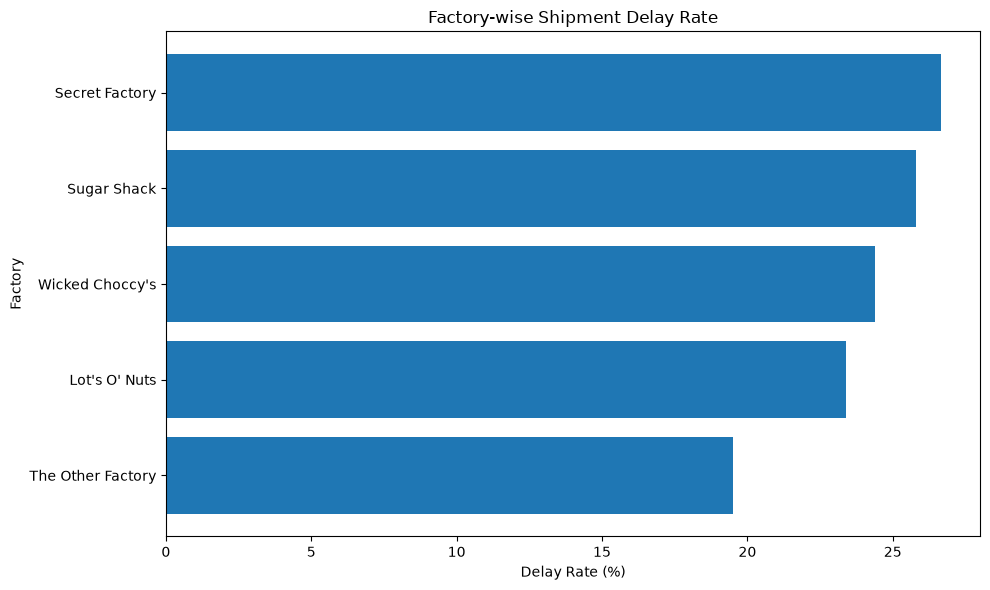

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

factory_chart = factory_impact.sort_values(
    "Delay_Rate_%",
    ascending=True
)

plt.barh(
    factory_chart.index,
    factory_chart["Delay_Rate_%"]
)

plt.xlabel("Delay Rate (%)")
plt.ylabel("Factory")
plt.title("Factory-wise Shipment Delay Rate")

plt.tight_layout()
plt.show()

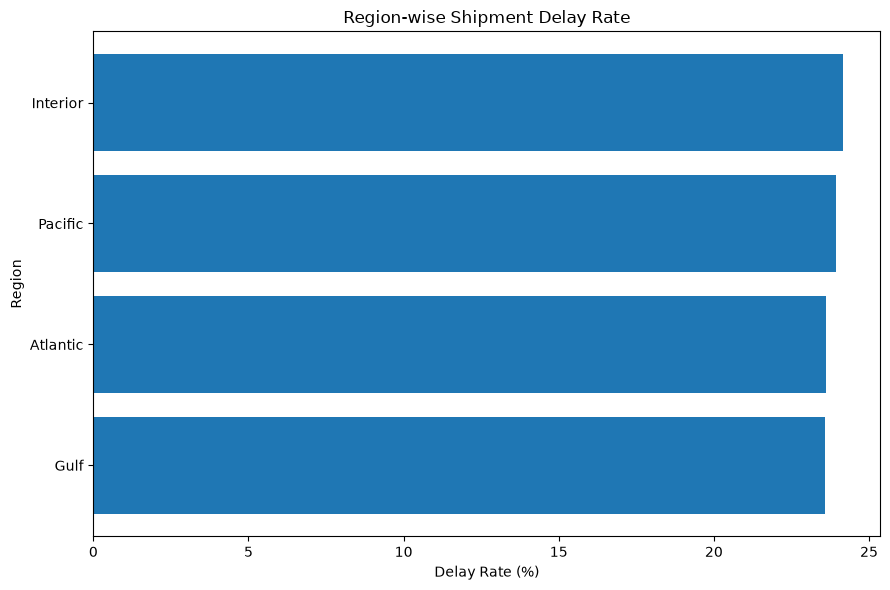

In [52]:
plt.figure(figsize=(9, 6))

region_chart = region_impact.sort_values(
    "Delay_Rate_%",
    ascending=True
)

plt.barh(
    region_chart.index,
    region_chart["Delay_Rate_%"]
)

plt.xlabel("Delay Rate (%)")
plt.ylabel("Region")
plt.title("Region-wise Shipment Delay Rate")

plt.tight_layout()
plt.show()

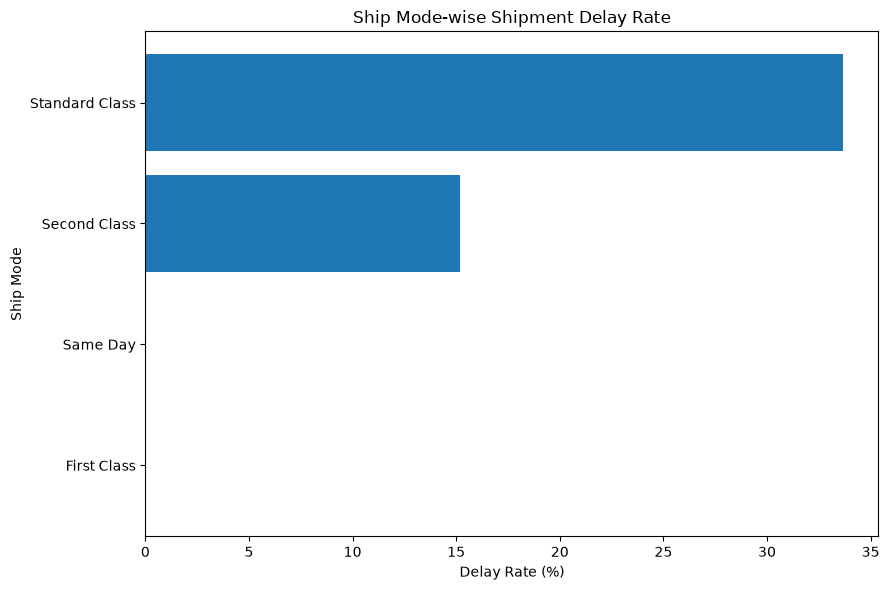

In [53]:
plt.figure(figsize=(9, 6))

ship_mode_chart = ship_mode_impact.sort_values(
    "Delay_Rate_%",
    ascending=True
)

plt.barh(
    ship_mode_chart.index,
    ship_mode_chart["Delay_Rate_%"]
)

plt.xlabel("Delay Rate (%)")
plt.ylabel("Ship Mode")
plt.title("Ship Mode-wise Shipment Delay Rate")

plt.tight_layout()
plt.show()

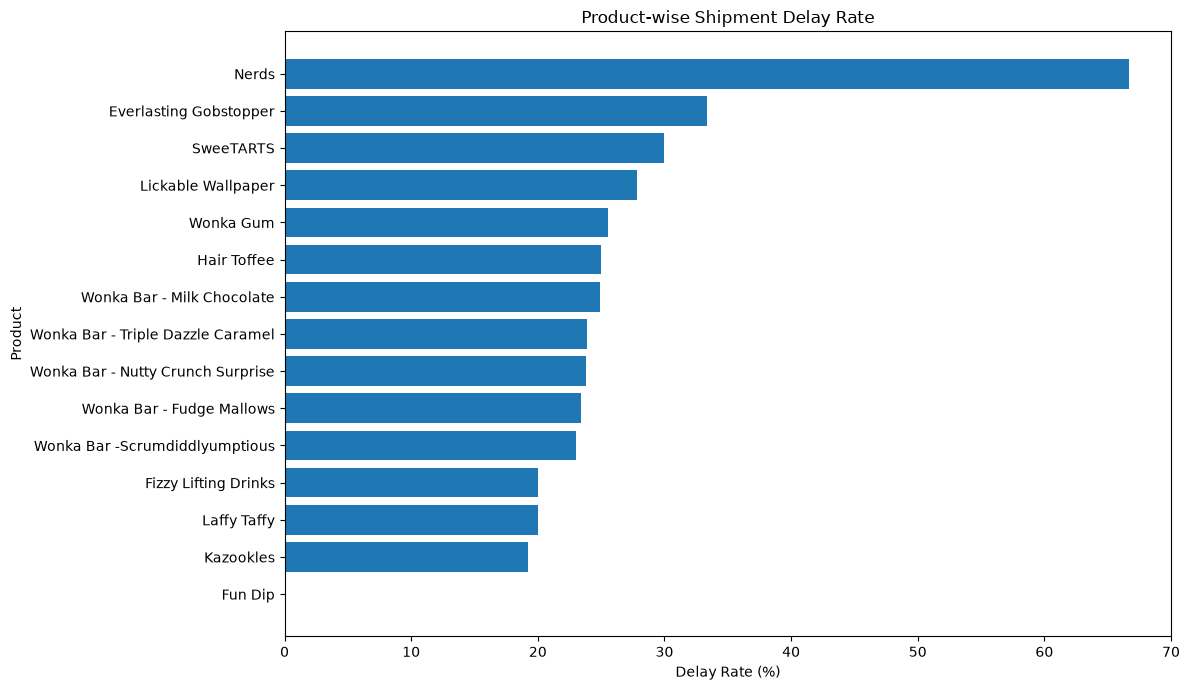

In [54]:
plt.figure(figsize=(12, 7))

product_chart = product_impact.sort_values(
    "Delay_Rate_%",
    ascending=True
)

plt.barh(
    product_chart.index,
    product_chart["Delay_Rate_%"]
)

plt.xlabel("Delay Rate (%)")
plt.ylabel("Product")
plt.title("Product-wise Shipment Delay Rate")

plt.tight_layout()
plt.show()

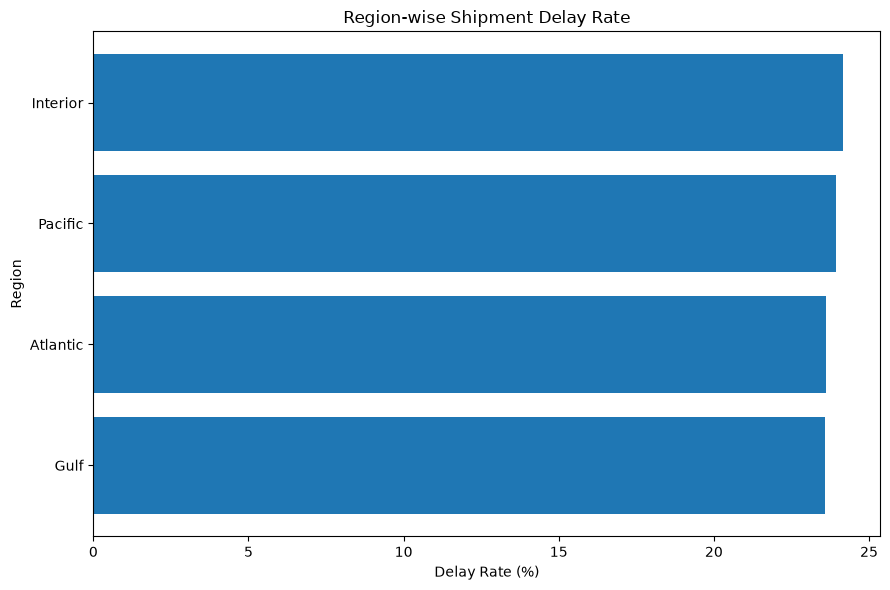

In [55]:
plt.figure(figsize=(9, 6))

region_chart = region_impact.sort_values(
    "Delay_Rate_%",
    ascending=True
)

plt.barh(
    region_chart.index,
    region_chart["Delay_Rate_%"]
)

plt.xlabel("Delay Rate (%)")
plt.ylabel("Region")
plt.title("Region-wise Shipment Delay Rate")

plt.tight_layout()
plt.show()

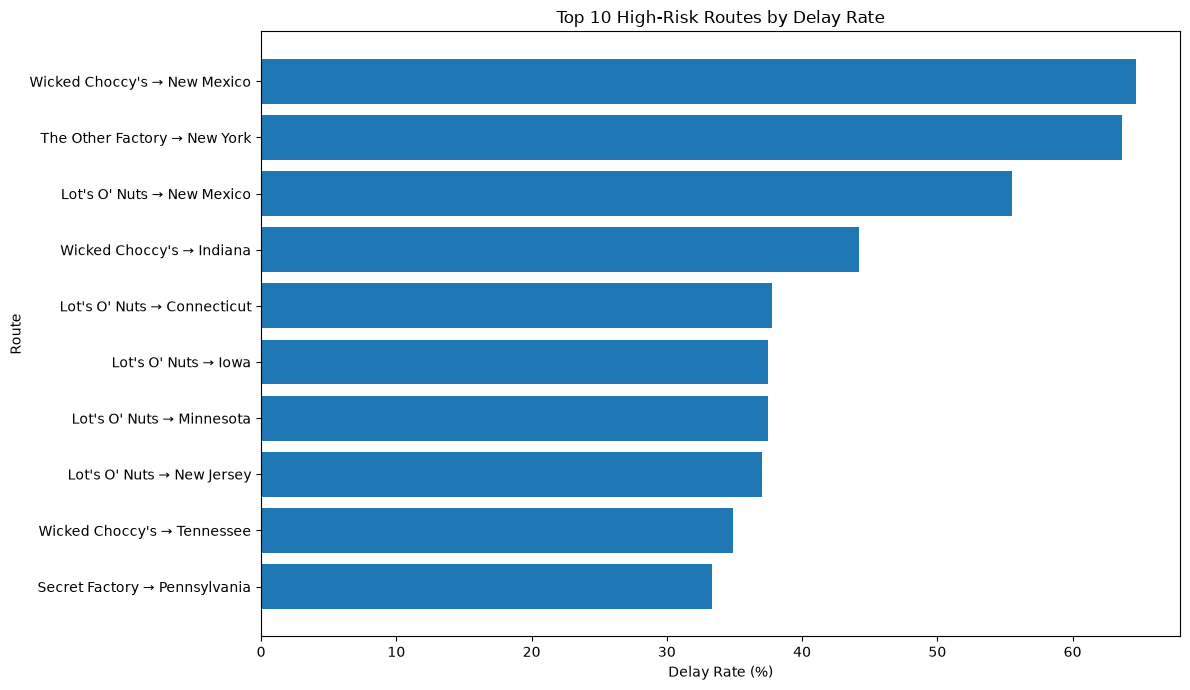

In [57]:
top_routes = high_risk_routes.head(10).sort_values(
    "Delay_Rate_%",
    ascending=True
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_routes.index,
    top_routes["Delay_Rate_%"]
)

plt.xlabel("Delay Rate (%)")
plt.ylabel("Route")
plt.title("Top 10 High-Risk Routes by Delay Rate")

plt.tight_layout()
plt.show()

<Figure size 900x600 with 0 Axes>

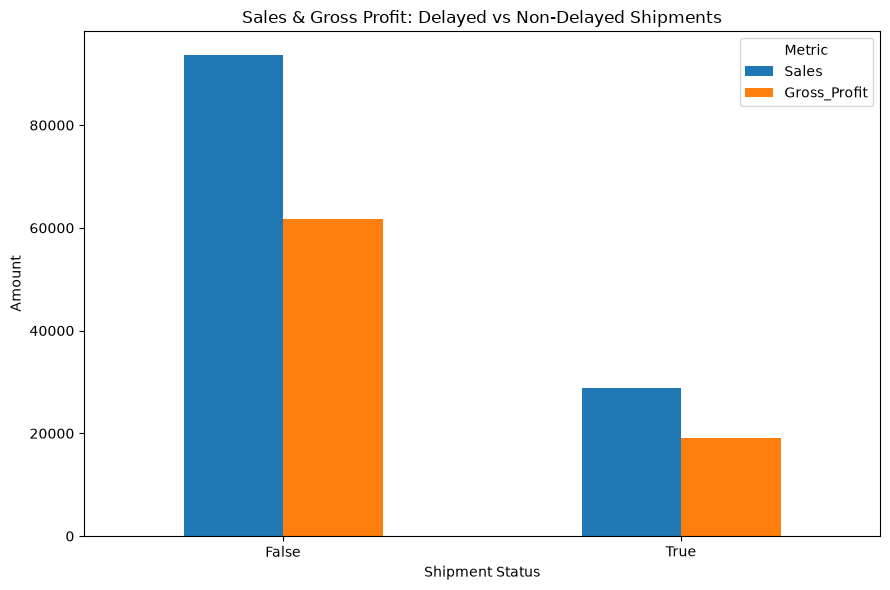

In [58]:
plt.figure(figsize=(9, 6))

delay_business = delay_impact[["Sales", "Gross_Profit"]]

delay_business.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.xlabel("Shipment Status")
plt.ylabel("Amount")
plt.title("Sales & Gross Profit: Delayed vs Non-Delayed Shipments")
plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

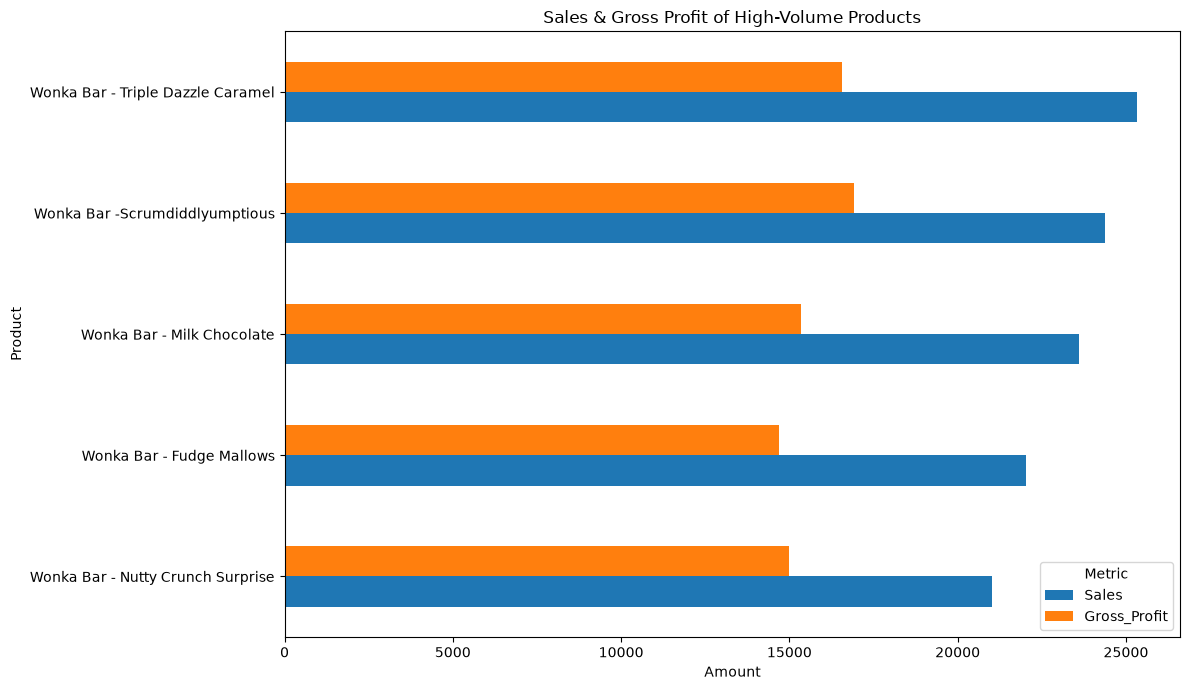

In [60]:
plt.figure(figsize=(12, 7))

high_volume_product_names = high_volume_products.index

product_business = product_impact.loc[
    product_impact.index.intersection(high_volume_product_names),
    ["Sales", "Gross_Profit"]
].sort_values("Sales", ascending=True)

product_business.plot(
    kind="barh",
    figsize=(12, 7)
)

plt.xlabel("Amount")
plt.ylabel("Product")
plt.title("Sales & Gross Profit of High-Volume Products")
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

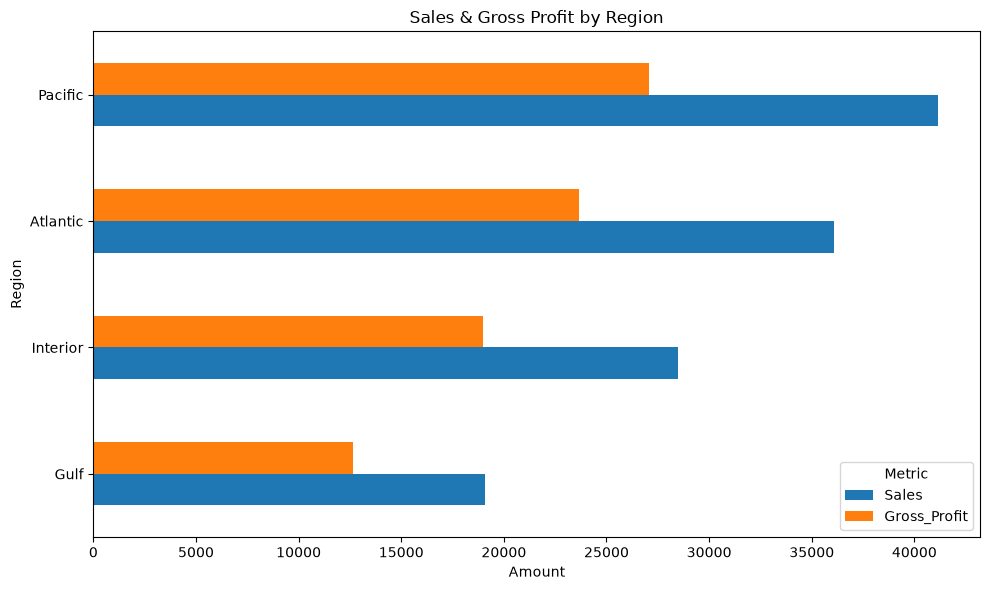

In [61]:
plt.figure(figsize=(10, 6))

region_business = region_impact[
    ["Sales", "Gross_Profit"]
].sort_values("Sales", ascending=True)

region_business.plot(
    kind="barh",
    figsize=(10, 6)
)

plt.xlabel("Amount")
plt.ylabel("Region")
plt.title("Sales & Gross Profit by Region")
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

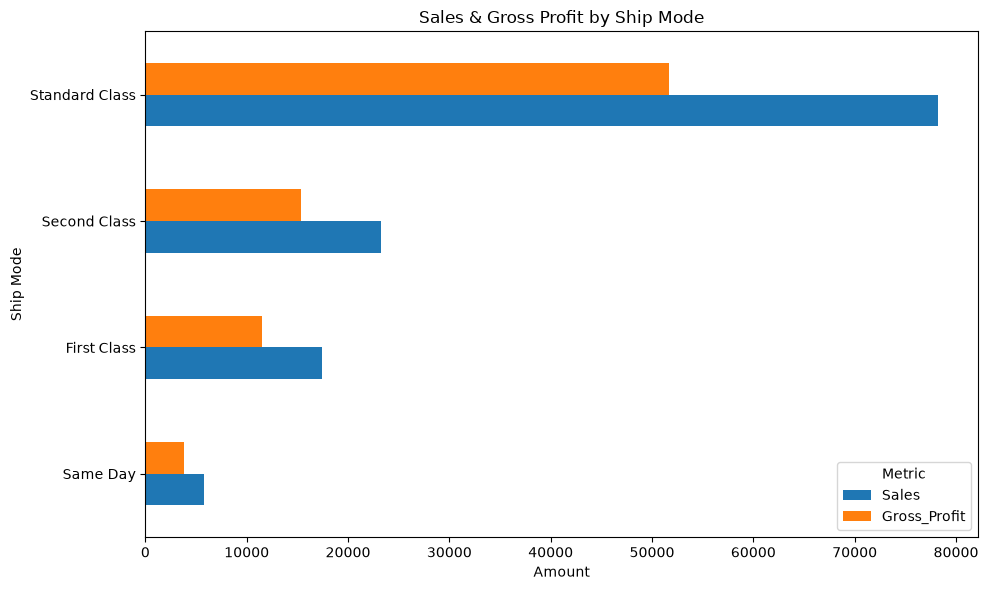

In [62]:
plt.figure(figsize=(10, 6))

ship_mode_business = ship_mode_impact[
    ["Sales", "Gross_Profit"]
].sort_values("Sales", ascending=True)

ship_mode_business.plot(
    kind="barh",
    figsize=(10, 6)
)

plt.xlabel("Amount")
plt.ylabel("Ship Mode")
plt.title("Sales & Gross Profit by Ship Mode")
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

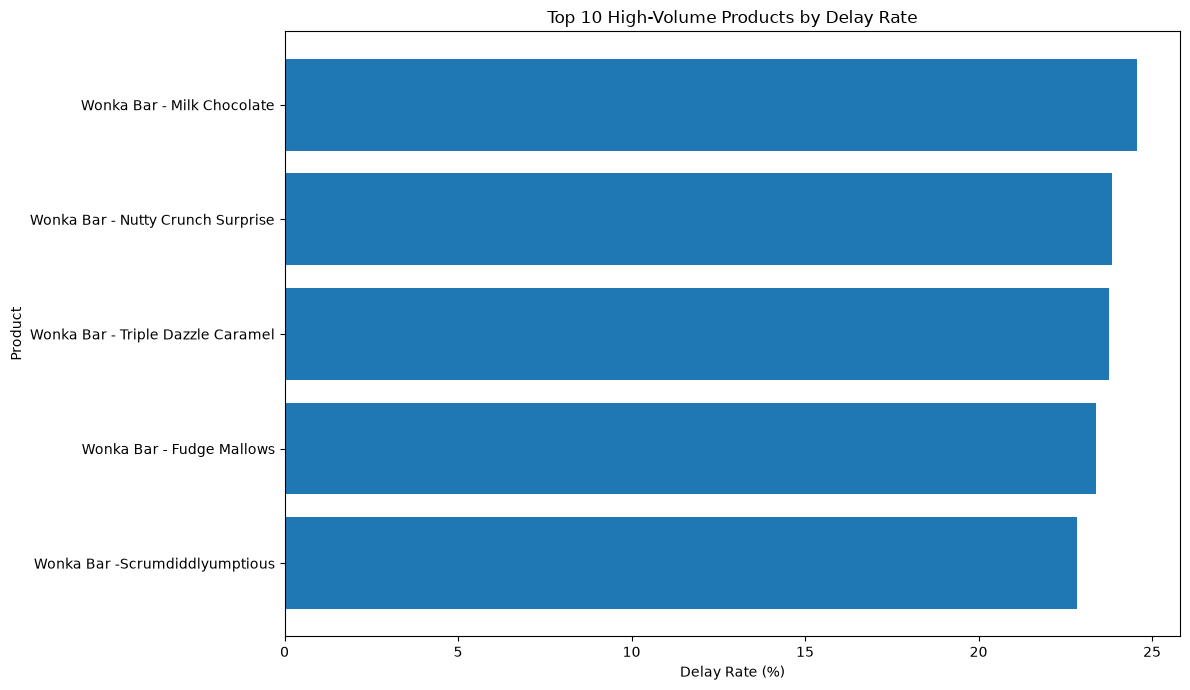

In [63]:
plt.figure(figsize=(12, 7))

top_products_delay = high_volume_products.sort_values(
    "Delay_Rate_%",
    ascending=True
).tail(10)

plt.barh(
    top_products_delay.index,
    top_products_delay["Delay_Rate_%"]
)

plt.xlabel("Delay Rate (%)")
plt.ylabel("Product")
plt.title("Top 10 High-Volume Products by Delay Rate")

plt.tight_layout()
plt.show()

In [64]:
import numpy as np

route_stats = route_kpi.copy()

correlation = route_stats[
    ["Shipment_Volume", "Average_Lead_Time"]
].corr().loc[
    "Shipment_Volume", "Average_Lead_Time"
]

print("Correlation between Route Volume and Average Lead Time:")
print(round(correlation, 3))

Correlation between Route Volume and Average Lead Time:
0.008


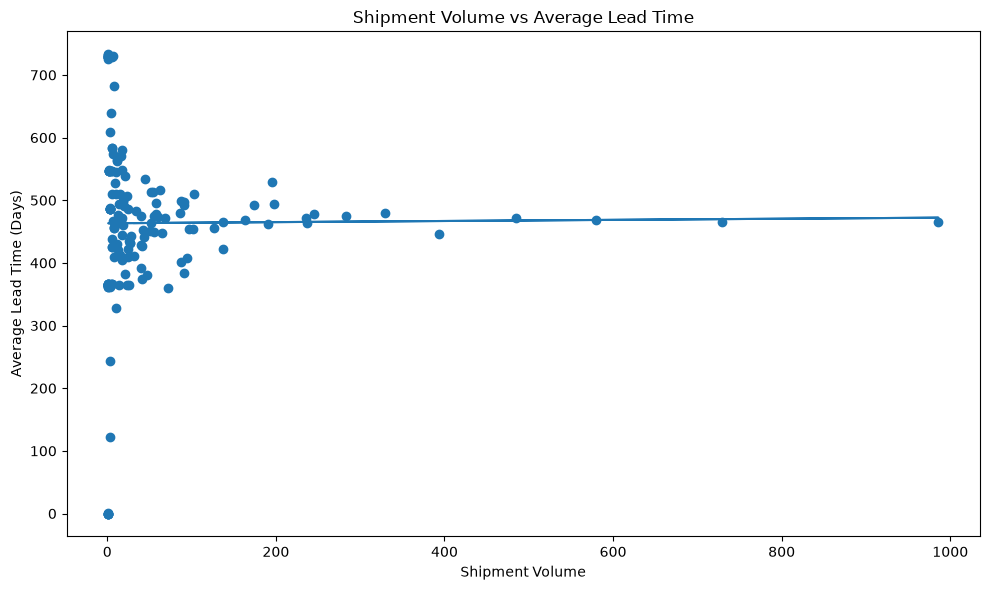

In [65]:
plt.figure(figsize=(10, 6))

x = route_kpi["Shipment_Volume"]
y = route_kpi["Average_Lead_Time"]

plt.scatter(x, y)

# Trend line
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.plot(x, p(x))

plt.xlabel("Shipment Volume")
plt.ylabel("Average Lead Time (Days)")
plt.title("Shipment Volume vs Average Lead Time")

plt.tight_layout()
plt.show()

In [66]:
correlation_delay_volume = route_kpi[
    ["Shipment_Volume", "Average_Lead_Time", "Lead_Time_Std"]
].corr()

print("ROUTE KPI CORRELATION MATRIX")
print("-" * 40)
print(correlation_delay_volume.round(3))

ROUTE KPI CORRELATION MATRIX
----------------------------------------
                   Shipment_Volume  Average_Lead_Time  Lead_Time_Std
Shipment_Volume              1.000              0.008          0.133
Average_Lead_Time            0.008              1.000         -0.228
Lead_Time_Std                0.133             -0.228          1.000


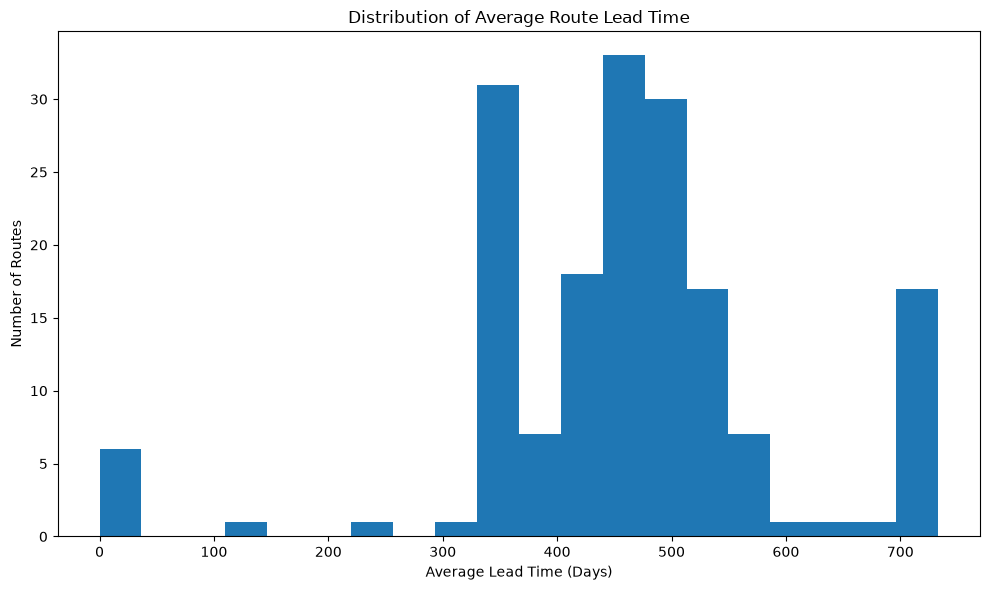

In [67]:
plt.figure(figsize=(10, 6))

plt.hist(
    route_kpi["Average_Lead_Time"],
    bins=20
)

plt.xlabel("Average Lead Time (Days)")
plt.ylabel("Number of Routes")
plt.title("Distribution of Average Route Lead Time")

plt.tight_layout()
plt.show()

In [69]:
print("route_kpi columns:")
print(route_kpi.columns.tolist())

print("\nhigh_risk_routes columns:")
print(high_risk_routes.columns.tolist())

route_kpi columns:
['Route', 'Shipment_Volume', 'Average_Lead_Time', 'Median_Lead_Time', 'Lead_Time_Std', 'Minimum_Lead_Time', 'Maximum_Lead_Time', 'Lead_Time_Range']

high_risk_routes columns:
['Shipment_Volume', 'Delayed_Shipments', 'Average_Lead_Time', 'Sales', 'Gross_Profit', 'Delay_Rate_%']


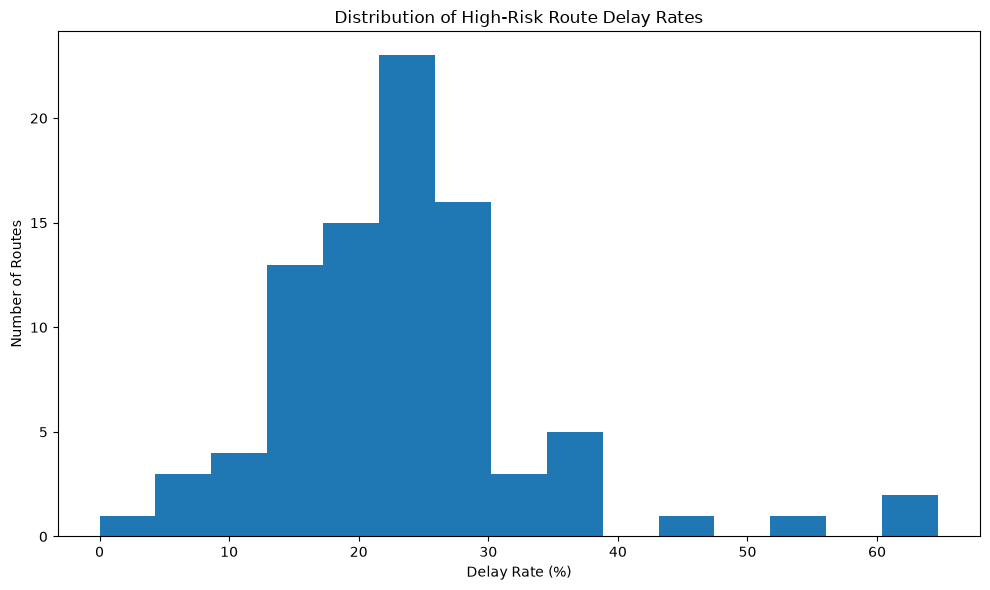

In [70]:
plt.figure(figsize=(10, 6))

plt.hist(
    high_risk_routes["Delay_Rate_%"],
    bins=15
)

plt.xlabel("Delay Rate (%)")
plt.ylabel("Number of Routes")
plt.title("Distribution of High-Risk Route Delay Rates")

plt.tight_layout()
plt.show()

In [71]:
slowest_routes = route_kpi.sort_values(
    "Average_Lead_Time",
    ascending=False
).head(10)

print("TOP 10 SLOWEST ROUTES")
print("-" * 40)
print(
    slowest_routes[
        [
            "Route",
            "Shipment_Volume",
            "Average_Lead_Time",
            "Median_Lead_Time",
            "Lead_Time_Range"
        ]
    ].round(2)
)

TOP 10 SLOWEST ROUTES
----------------------------------------
                               Route  Shipment_Volume  Average_Lead_Time  \
90          Sugar Shack → New Jersey                1             733.00   
67    Secret Factory → New Hampshire                1             732.00   
85         Sugar Shack → Connecticut                1             732.00   
163   Wicked Choccy's → South Dakota                1             731.00   
39      Lot's O' Nuts → South Dakota                7             730.86   
170  Wicked Choccy's → West Virginia                2             730.00   
32      Lot's O' Nuts → North Dakota                5             729.20   
84          Sugar Shack → California                1             729.00   
54      Secret Factory → Connecticut                1             729.00   
97          Sugar Shack → Washington                1             729.00   

     Median_Lead_Time  Lead_Time_Range  
90              733.0                0  
67              73

In [72]:
high_volume_routes = (
    high_risk_routes[
        high_risk_routes["Shipment_Volume"] >= 20
    ]
    .sort_values("Delay_Rate_%", ascending=False)
)

print("HIGH-VOLUME ROUTES WITH HIGHEST DELAY RATE")
print("-" * 50)

print(
    high_volume_routes[
        [
            "Shipment_Volume",
            "Delayed_Shipments",
            "Delay_Rate_%",
            "Average_Lead_Time",
            "Sales"
        ]
    ]
    .head(10)
    .round(2)
)

HIGH-VOLUME ROUTES WITH HIGHEST DELAY RATE
--------------------------------------------------
                              Shipment_Volume  Delayed_Shipments  \
Route                                                              
Wicked Choccy's → Indiana                  52                 23   
Lot's O' Nuts → Connecticut                45                 17   
Lot's O' Nuts → Minnesota                  40                 15   
Lot's O' Nuts → New Jersey                 54                 20   
Wicked Choccy's → Tennessee                63                 22   
Lot's O' Nuts → Tennessee                 103                 34   
Wicked Choccy's → Minnesota                42                 13   
Wicked Choccy's → Washington              195                 58   
Lot's O' Nuts → Missouri                   34                 10   
Lot's O' Nuts → Florida                   174                 50   

                              Delay_Rate_%  Average_Lead_Time    Sales  
Route           

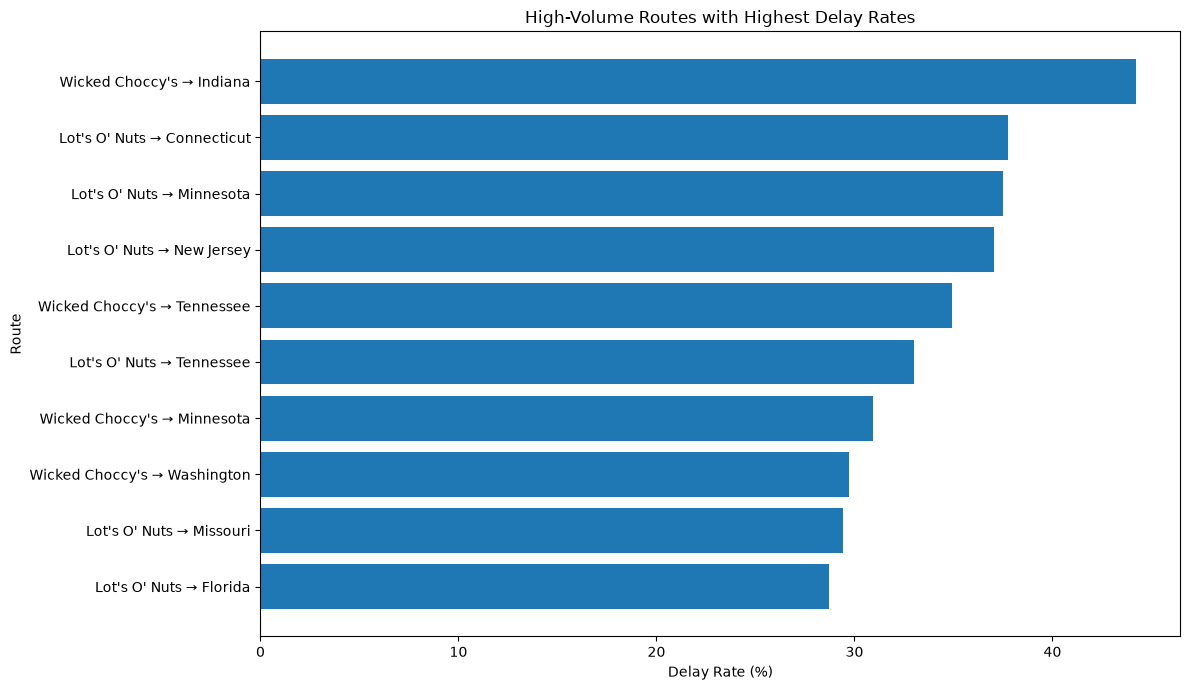

In [73]:
plt.figure(figsize=(12, 7))

top_hv_routes = high_volume_routes.head(10).sort_values(
    "Delay_Rate_%",
    ascending=True
)

plt.barh(
    top_hv_routes.index,
    top_hv_routes["Delay_Rate_%"]
)

plt.xlabel("Delay Rate (%)")
plt.ylabel("Route")
plt.title("High-Volume Routes with Highest Delay Rates")

plt.tight_layout()
plt.show()

# KEY FINDINGS

## 1. Overall Delivery Performance
- The dataset contains 10,194 total shipment records.
- After lead-time validation, 9,009 records were considered valid.
- The overall delay rate among valid US shipments is approximately 23.83%.
- The average adjusted lead time is 466.28 days, while the median is 365 days.

## 2. Factory Performance
- Secret Factory has the highest factory-level delay rate at approximately 26.67%.
- Sugar Shack follows with a delay rate of approximately 25.81%.
- The Other Factory has the lowest delay rate at approximately 19.51%.
- Lot's O' Nuts handles the largest shipment volume but has a delay rate of approximately 23.38%.

## 3. Regional Performance
- Interior has the highest regional delay rate at approximately 24.15%.
- Pacific follows at approximately 23.92%.
- Atlantic and Gulf have slightly lower delay rates of approximately 23.61% and 23.60%.

## 4. Ship Mode Performance
- Standard Class has the highest delay rate at approximately 33.68%.
- Second Class has a significantly lower delay rate of approximately 15.20%.
- First Class and Same Day shipments show 0% delay in the analyzed valid records.

## 5. High-Volume Route Risk
- Wicked Choccy's → Indiana has the highest delay rate among high-volume routes at 44.23%.
- Lot's O' Nuts → Connecticut has a delay rate of 37.78%.
- Lot's O' Nuts → Minnesota has a delay rate of 37.50%.
- Wicked Choccy's → Washington is particularly important because it combines a relatively high delay rate of 29.74% with 195 shipments.

## 6. Product Performance
- Wonka Bar - Milk Chocolate has the highest delayed shipment count among the major high-volume products, with 469 delayed shipments.
- Its delay rate is approximately 24.58%.
- Other major Wonka Bar products also show delay rates above 22%.

## 7. Statistical Finding
- The correlation between shipment volume and average lead time is approximately 0.008.
- This indicates almost no linear relationship between shipment volume and average lead time.
- Therefore, higher shipment volume alone does not appear to explain longer lead times.

## 8. Data Quality
- 1,185 records were identified with negative adjusted lead times and excluded from valid lead-time analysis.
- This validation step resulted in approximately 88.38% of the original records being retained for valid lead-time analysis.

# BUSINESS RECOMMENDATIONS

## 1. Prioritize High-Risk Routes
- Investigate routes with consistently high delay rates, especially Wicked Choccy's → Indiana and Lot's O' Nuts → Connecticut.
- Develop route-specific corrective actions for destinations with high delay frequency.
- Closely monitor high-volume routes where delays can affect a larger number of shipments.

## 2. Improve Standard Class Shipments
- Standard Class has the highest delay rate at approximately 33.68%.
- Review the operational process, transit planning, and carrier performance associated with Standard Class shipments.
- Where operationally feasible, consider shifting critical shipments to faster shipping modes.

## 3. Address Factory-Level Delays
- Secret Factory and Sugar Shack have the highest factory-level delay rates.
- Management should investigate production scheduling, order processing, inventory availability, and dispatch delays at these facilities.
- Performance should be monitored regularly using factory-level KPIs.

## 4. Focus on High-Volume Products
- Major Wonka Bar products account for substantial shipment volumes and delayed shipments.
- Improving fulfillment and dispatch performance for these products could have a significant overall impact.
- High-volume products should receive priority in inventory and shipment planning.

## 5. Monitor Regional Performance
- Interior has the highest regional delay rate among the four regions.
- Regional logistics performance should be reviewed to identify recurring transportation or operational bottlenecks.
- Region-wise KPIs should be tracked regularly.

## 6. Use Data-Driven Route Planning
- Route volume has almost no correlation with average lead time, with a correlation coefficient of approximately 0.008.
- Therefore, route optimization should not rely only on shipment volume.
- Other factors such as destination, factory, shipping mode, and historical delay performance should be considered.

## 7. Establish Regular KPI Monitoring
- Track delay rate, average lead time, shipment volume, and route-level performance regularly.
- Create a dashboard to identify emerging high-risk routes and operational issues.
- Use historical performance to support proactive logistics decisions.

## 8. Improve Data Quality
- Negative lead-time records should be investigated at the source.
- Data validation rules should be implemented before analysis to prevent incorrect dates and lead-time values from affecting business decisions.

# EXECUTIVE SUMMARY

## Nassau Candy Route Efficiency Analysis

This project analyzes shipment and route performance for Nassau Candy Distributor using shipment, lead-time, sales, profit, factory, region, product, and shipping-mode data.

### Key Findings

- The dataset contains **10,194 total records**.
- After lead-time validation, **9,009 records** were identified as valid.
- The overall delay rate among valid US shipments is approximately **23.83%**.
- The average lead time is approximately **466.28 days**, while the median lead time is **365 days**.
- The analysis covers **5 factories, 191 routes, and 59 states**.

### Delay Performance

- **2,147 shipments** were identified as delayed in the overall valid dataset.
- **Standard Class** has the highest shipping-mode delay rate at approximately **33.68%**.
- **Secret Factory** has the highest factory-level delay rate at approximately **26.67%**.
- **Interior** has the highest regional delay rate at approximately **24.15%**.

### High-Risk Routes

Several routes show significantly higher delay rates than the overall average.

The highest-risk high-volume route identified is:

**Wicked Choccy's → Indiana**
- Shipment Volume: 52
- Delayed Shipments: 23
- Delay Rate: 44.23%
- Average Lead Time: 512.56 days

Other high-risk routes include:
- Lot's O' Nuts → Connecticut — 37.78% delay rate
- Lot's O' Nuts → Minnesota — 37.50%
- Lot's O' Nuts → New Jersey — 37.04%
- Wicked Choccy's → Tennessee — 34.92%

### Product Performance

The major Wonka Bar products account for a substantial proportion of shipment volume. Therefore, delays affecting these products can have a significant operational impact.

Among the high-volume products:
- Wonka Bar - Milk Chocolate has a delay rate of approximately 24.58%.
- Wonka Bar - Nutty Crunch Surprise has a delay rate of approximately 23.86%.
- Wonka Bar - Triple Dazzle Caramel has a delay rate of approximately 23.77%.

### Business Impact

The valid dataset represents approximately:

- **Total Sales:** 124,778.22
- **Total Gross Profit:** 82,356.49
- **Total Units:** 34,090

The analysis indicates that improving logistics performance, particularly on high-risk routes and Standard Class shipments, could help reduce operational inefficiencies.

### Important Analytical Insight

The correlation between route shipment volume and average lead time is approximately **0.008**, indicating almost no linear relationship between route volume and average lead time.

This suggests that simply increasing or decreasing shipment volume is unlikely to explain route lead-time performance. Other factors such as factory, destination, shipping mode, and operational conditions should therefore be considered.

### Conclusion

The analysis identifies specific routes, factories, regions, products, and shipping modes that require closer monitoring. A data-driven logistics strategy should prioritize high-risk routes, improve Standard Class performance, investigate factory-level delays, and continuously monitor route-level KPIs.

The findings can support better route planning, shipment prioritization, operational monitoring, and logistics decision-making.

# PROJECT COMPLETION

## Nassau Candy Route Efficiency Analysis

### Project Status: Completed

The project successfully analyzes shipment delays, route efficiency, lead-time performance, factory and regional performance, shipping modes, product-level delays, and business impact.

### Analysis Completed

- Data validation and cleaning
- Lead-time analysis
- US shipment filtering
- Route KPI analysis
- Delay frequency analysis
- Factory-wise analysis
- Region-wise analysis
- State-wise analysis
- Ship-mode analysis
- Product-wise analysis
- Business impact analysis
- High-risk route identification
- Correlation analysis
- Data visualizations
- Executive summary

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

### Final Outcome

The analysis identifies major operational bottlenecks and high-risk routes that can be prioritized for logistics improvement and better shipment planning.

In [75]:
import os
import matplotlib.pyplot as plt

# Create outputs folder if it does not exist
os.makedirs("../outputs", exist_ok=True)

# 1. Factory-wise Delay Rate
factory_plot = factory_impact["Delay_Rate_%"].sort_values()

plt.figure(figsize=(10, 6))
factory_plot.plot(kind="barh")
plt.title("Factory-wise Shipment Delay Rate")
plt.xlabel("Delay Rate (%)")
plt.ylabel("Factory")
plt.tight_layout()
plt.savefig("../outputs/factory_delay_rate.png", dpi=300, bbox_inches="tight")
plt.close()


# 2. Region-wise Delay Rate
region_plot = region_impact["Delay_Rate_%"].sort_values()

plt.figure(figsize=(10, 6))
region_plot.plot(kind="bar")
plt.title("Region-wise Shipment Delay Rate")
plt.xlabel("Region")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/region_delay_rate.png", dpi=300, bbox_inches="tight")
plt.close()


# 3. Ship Mode-wise Delay Rate
ship_plot = ship_mode_impact["Delay_Rate_%"].sort_values()

plt.figure(figsize=(10, 6))
ship_plot.plot(kind="bar")
plt.title("Ship Mode-wise Shipment Delay Rate")
plt.xlabel("Ship Mode")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/ship_mode_delay_rate.png", dpi=300, bbox_inches="tight")
plt.close()


# 4. Product-wise Delay Rate
product_plot = product_impact["Delay_Rate_%"].sort_values(ascending=False).head(10)

plt.figure(figsize=(11, 6))
product_plot.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Delay Rate")
plt.xlabel("Delay Rate (%)")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("../outputs/top_products_delay_rate.png", dpi=300, bbox_inches="tight")
plt.close()


# 5. High-Risk Routes
route_plot = high_risk_routes["Delay_Rate_%"].sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))
route_plot.sort_values().plot(kind="barh")
plt.title("Top 10 High-Risk Routes by Delay Rate")
plt.xlabel("Delay Rate (%)")
plt.ylabel("Route")
plt.tight_layout()
plt.savefig("../outputs/top_high_risk_routes.png", dpi=300, bbox_inches="tight")
plt.close()


print("SUCCESS: All charts saved in outputs folder.")

SUCCESS: All charts saved in outputs folder.
